In [1]:
# import os

# if "COLAB_GPU" in os.environ:
#   print('ok')
#   # !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
#   !pip install PyMuPDF
#   !pip install sentence-transformers # for embedding models
#   !pip install tqdm
#   !pip install accelerate
#   !pip install bitsandbytes
  # !pip install flash-attn --no-build-isolation

In [2]:
# !pip uninstall -y torch torchvision torchaudio transformers sentence-transformers
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install -U transformers sentence-transformers

In [3]:
!pip install PyMuPDF
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 25.8 MB/s eta 0:00:00


### Download and load the Data file

In [4]:
import os
import requests

pdf_path = "ML.pdf"

# Download pdf if doesn`t exits
if not os.path.exists(pdf_path):
  print("File does not exist")

  # The URL of the PDF of Download
  url = 'https://shashwatwork.github.io/assets/files/ml_ebook.pdf'

  filename=pdf_path

  # send the GET request to download the PDF

  response = requests.get(url)

  # check if the request was successful
  if response.status_code == 200:
    # open a file in binary write mode and save the contant it
    with open(filename, 'wb') as file:
      file.write(response.content)
    print(f'write the file has been downloaded and saved as {filename}')
  else:
    print(f'the file failed to download status code: {response.status_code}')
else:
  print(f"file {pdf_path} exists")


File does not exist
write the file has been downloaded and saved as ML.pdf


### Read the Data file and save structure format

In [5]:
from tqdm.auto import tqdm
import fitz #PyMuPDF

def text_formater(text:str) -> str:
  """ Perform the minner formatting """
  cleaned_text=text.replace("\n", " ").strip()

  return cleaned_text
# Note: focus on only text rather than images and table

def open_and_read_pdf(pdf_path:str)->list[dict]:
  """
  Open : the pdf and read the text page by page

  Parameter get function:
    pdf_path the file path your pdf to open and read the document
  Return:
    list of and dictionary fromat [{}, {}] to return this function

  """
  docs = fitz.open(pdf_path)
  page_and_text=[]

  for page_number , page in tqdm(enumerate(docs)):
    text=page.get_text()
    text=text_formater(text)
    page_and_text.append({
        "page_number": page_number,
        "page_total_words": len(text.split(' ')),
        "page_total_char": len(text),
        "page_total_sentence": len(text.split('. ')),
        "page_total_token": len(text) /4,
        "text": text
    })

  return page_and_text


page_and_text = open_and_read_pdf(pdf_path=pdf_path)
page_and_text[:2]

0it [00:00, ?it/s]

[{'page_number': 0,
  'page_total_words': 1,
  'page_total_char': 0,
  'page_total_sentence': 1,
  'page_total_token': 0.0,
  'text': ''},
 {'page_number': 1,
  'page_total_words': 1,
  'page_total_char': 0,
  'page_total_sentence': 1,
  'page_total_token': 0.0,
  'text': ''}]

In [6]:
import random
random.sample(page_and_text, k=1) # read the random sample of data

[{'page_number': 173,
  'page_total_words': 369,
  'page_total_char': 1839,
  'page_total_sentence': 16,
  'page_total_token': 459.75,
  'text': '6 The objective function is convex, and the inequality constraints are continuously differentiable and convex functions. • nc = m, where m is the number of training instances. • H is the np × np identity matrix, except with a zero in the top-left cell (to ignore the bias term). • f = 0, an np-dimensional vector full of 0s. • b = –1, an nc-dimensional vector full of –1s. • a(i) = –t(i) x˙ (i), where x˙ (i) is equal to x(i) with an extra bias feature x˙ 0 = 1. So one way to train a hard margin linear SVM classifier is just to use an off-the-shelf QP solver by passing it the preceding parameters. The resulting vector p will contain the bias term b = p0 and the feature weights wi = pi for i = 1, 2, ⋯, n. Similarly, you can use a QP solver to solve the soft margin problem (see the exercises at the end of the chapter). However, to use the kernel tr

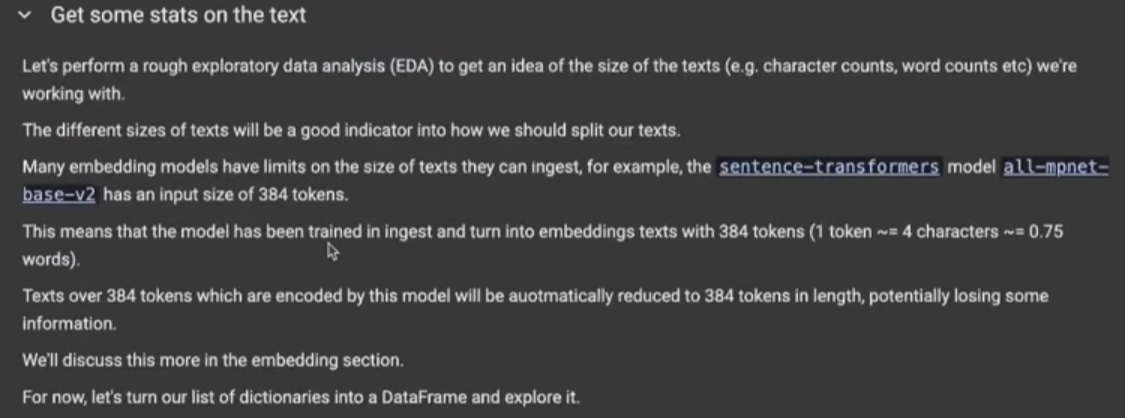

In [7]:
import pandas as pd
data=pd.DataFrame(page_and_text)
data.describe()

,page_number,page_total_words,page_total_char,page_total_sentence,page_total_token
count,279.000000,279.000000,279.000000,279.000000,279.000000
mean,139.000000,335.738351,1750.713262,13.591398,437.678315
std,80.684571,408.443051,691.596170,12.272303,172.899043
min,0.000000,1.000000,0.000000,1.000000,0.000000
25%,69.500000,222.000000,1367.500000,9.000000,341.875000
50%,139.000000,302.000000,1786.000000,12.000000,446.500000
75%,208.500000,356.500000,2124.500000,15.000000,531.125000
max,278.000000,3948.000000,4918.000000,124.000000,1229.500000


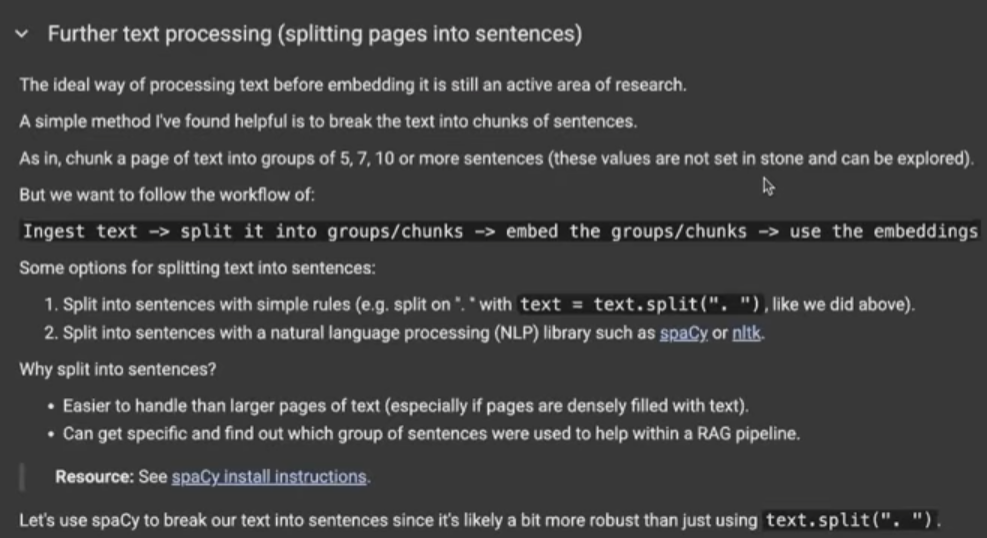

In [8]:
# Example Code how its work spacy tool

from spacy.lang.en import English
nlp = English()
# add a sentencizer pipline
nlp.add_pipe("sentencizer")

docs=nlp("My name is Inam! i from Pakistan")

assert len(list(docs.sents)) ==2

list(docs.sents)

[My name is Inam!, i from Pakistan]

In [9]:
for items in tqdm(page_and_text):
  items['sentences'] = list(nlp(items['text']).sents)

  # ensure that all sentence in string data type
  items['sentences']=[str(sentence) for sentence in items['sentences']]

  items["page_senetnce_count_spacy"] = len(items['sentences'])

  0%|          | 0/279 [00:00<?, ?it/s]

In [10]:
random.sample(page_and_text, k=2)

[{'page_number': 93,
  'page_total_words': 278,
  'page_total_char': 1785,
  'page_total_sentence': 13,
  'page_total_token': 446.25,
  'text': 'Training a Binary Classifier Let’s simplify the problem for now and only try to identify one digit—for example, the number 5. This “5-detector” will be an example of a binary classifier, capable of distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for this classification task: y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits. y_test_5 = (y_test == 5) Okay, now let’s pick a classifier and train it. A good place to start is with a Stochastic Gradient Descent (SGD) classifier, using Scikit-Learn’s SGDClassifier class. This clas‐ sifier has the advantage of being capable of handling very large datasets efficiently. This is in part because SGD deals with training instances independently, one at a time (which also makes SGD well suited for online learning), as we will see later. Let’s crea

In [11]:
df=pd.DataFrame(page_and_text)
df.describe()

,page_number,page_total_words,page_total_char,page_total_sentence,page_total_token,page_senetnce_count_spacy
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,139.000000,335.738351,1750.713262,13.591398,437.678315,12.623656
std,80.684571,408.443051,691.596170,12.272303,172.899043,5.749408
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,69.500000,222.000000,1367.500000,9.000000,341.875000,9.000000
50%,139.000000,302.000000,1786.000000,12.000000,446.500000,12.000000
75%,208.500000,356.500000,2124.500000,15.000000,531.125000,16.000000
max,278.000000,3948.000000,4918.000000,124.000000,1229.500000,42.000000


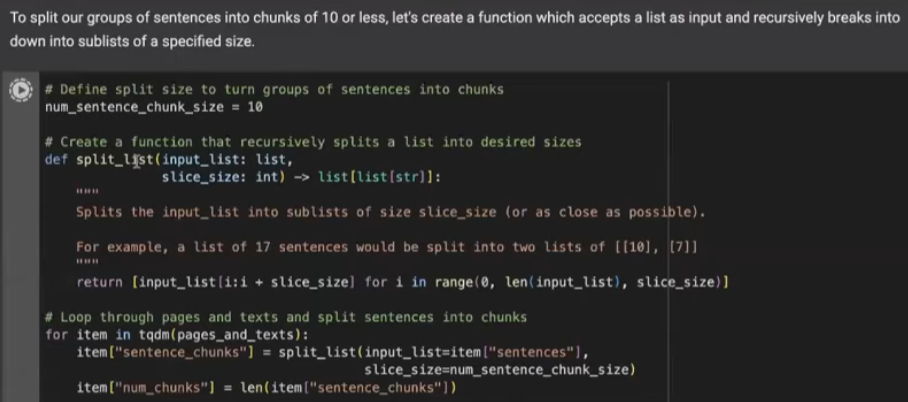

To Split our groups of sentences into chunks of 10 or less, lets create a function which accepts a list as input and recursively break into down into sublist of a specified size.

---
min: 1 sentence (kuch pages mein sirf 1 sentence hai!)

max: 124 sentences (kuch pages mein 124 tak sentences hain!)

mean: ~13.59 sentences

50% (median): 12 sentences

Page 1: 10 sentences → 1 chunk [10]

Page 50: 25 sentences → 3 chunks [10, 10, 5]

Page 100: 124 sentences → 13 chunks [10, 10, 10, ... 4]

In [12]:
# Define the number to each sentence chunk length.
number_spilt_chunk_size=10

def split_chunk(input_list:list, slice_size:int) -> list[list[str]]:
  """
  Split the list into sublists of size slice_size (or as close as possible)

  Example , a list of 17 sentences would be split into two list of [[10], [7]]
  """
  return [input_list[i:i+slice_size] for i in range(0, len(input_list), slice_size)]


for item in tqdm(page_and_text):

   item['sentence_chunk']=split_chunk(input_list=item['sentences'], slice_size=number_spilt_chunk_size)

   item['sentence_chunk_len']=len(item['sentence_chunk'])


  0%|          | 0/279 [00:00<?, ?it/s]

In [13]:
df=pd.DataFrame(page_and_text)
df['sentence_chunk'].head()
df.head()

,page_number,page_total_words,page_total_char,page_total_sentence,page_total_token,text,sentences,page_senetnce_count_spacy,sentence_chunk,sentence_chunk_len
0,0,1,0,1,0.00,,[],0,[],0
1,1,1,0,1,0.00,,[],0,[],0
2,2,30,237,1,59.25,Aurélien Géron Hands-on Machine Learning with ...,[Aurélien Géron Hands-on Machine Learning with...,1,[[Aurélien Géron Hands-on Machine Learning wit...,1
3,3,249,1777,14,444.25,978-1-492-03264-9 [LSI] Hands-on Machine Learn...,[978-1-492-03264-9 [LSI] Hands-on Machine Lear...,11,[[978-1-492-03264-9 [LSI] Hands-on Machine Lea...,2
4,4,2467,3246,90,811.50,Table of Contents 1. The Machine Learning Land...,"[Table of Contents 1., The Machine Learning La...",7,"[[Table of Contents 1., The Machine Learning L...",1


In [14]:
import random
random.sample(page_and_text, k=1)

[{'page_number': 145,
  'page_total_words': 239,
  'page_total_char': 1457,
  'page_total_sentence': 11,
  'page_total_token': 364.25,
  'text': '>>> elastic_net.fit(X, y) >>> elastic_net.predict([[1.5]]) array([1.54333232]) Early Stopping A very different way to regularize iterative learning algorithms such as Gradient Descent is to stop training as soon as the validation error reaches a minimum. This is called early stopping. Figure 4-20 shows a complex model (in this case a high-degree Polynomial Regression model) being trained using Batch Gradient Descent. As the epochs go by, the algorithm learns and its prediction error (RMSE) on the training set naturally goes down, and so does its prediction error on the validation set. However, after a while the validation error stops decreasing and actually starts to go back up. This indicates that the model has started to overfit the training data. With early stop‐ ping you just stop training as soon as the validation error reaches the minim

### Split the chunk on each item.

In [15]:
for items in tqdm(page_and_text):
  for sentence_chunk in items['sentences']:
    print(sentence_chunk)
    break


  0%|          | 0/279 [00:00<?, ?it/s]

Aurélien Géron Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow Concepts, Tools, and Techniques to Build Intelligent Systems SECOND EDITION Boston Farnham Sebastopol Tokyo Beijing Boston Farnham Sebastopol Tokyo Beijing
978-1-492-03264-9 [LSI] Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurélien Géron Copyright © 2019 O’Reilly Media.
Table of Contents 1.
Create a Test Set                                                                                                            57 Discover and Visualize the Data to Gain Insights                                                       61 Visualizing Geographical Data                                                                                   62 Looking for Correlations                                                                                             64 Experimenting with Attribute Combinations                                                          67 Prepare the Data for Machine

In [16]:
import re

pages_and_chunks=[]

for items in tqdm(page_and_text):
  for sentence_chunk in items['sentences']:
    chunk_dict={}
    chunk_dict['page_number']=items['page_number']

    joined_sentence_chunk="".join(sentence_chunk).replace("  ", " ").strip()
    joined_sentence_chunk=re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)
    chunk_dict['sentence_chunk']=joined_sentence_chunk



    chunk_dict['chunk_char_count']=len(joined_sentence_chunk)
    chunk_dict['chunk_word_count']=len([word for word in joined_sentence_chunk.split(" ")])
    chunk_dict['chunk_token_count']=len(joined_sentence_chunk)/4

    pages_and_chunks.append(chunk_dict)


len(pages_and_chunks)

  0%|          | 0/279 [00:00<?, ?it/s]

3522

In [17]:
df_page_and_chunk=pd.DataFrame(pages_and_chunks)

df_page_and_chunk.describe()

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,3522.000000,3522.000000,3522.000000,3522.000000
mean,141.444066,135.110449,23.942078,33.777612
std,79.761312,129.216482,42.346310,32.304120
min,2.000000,1.000000,1.000000,0.250000
25%,71.000000,60.000000,10.000000,15.000000
50%,142.000000,112.000000,19.000000,28.000000
75%,209.750000,174.000000,29.000000,43.500000
max,278.000000,1564.000000,974.000000,391.000000


In [18]:
import numpy as np

In [19]:
np.__version__

'2.0.2'

In [20]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 245,
  'sentence_chunk': '>>> X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]]) >>> kmeans.predict(X_new) array([1, 1, 2, 2], dtype=int32) If you plot the cluster’s decision boundaries, you get a Voronoi tessellation (see Figure 9-3, where each centroid is represented with an X): Figure 9-3.',
  'chunk_char_count': 271,
  'chunk_word_count': 43,
  'chunk_token_count': 67.75}]

In [21]:
min_token_length=30

for row in df_page_and_chunk[df_page_and_chunk['chunk_token_count'] <= min_token_length].sample(2).iterrows():
  print(f"Chunk token count : {row[1]['chunk_token_count']} | Text: {row[1]['sentence_chunk']}")

Chunk token count : 14.0 | Text: You may be wondering how to perform this reconstruction.
Chunk token count : 0.75 | Text: 10.


In [22]:
page_chunk_over_min_token=df_page_and_chunk[df_page_and_chunk['chunk_token_count'] > min_token_length].to_dict(orient='records')
page_chunk_over_min_token[:1]

[{'page_number': 2,
  'sentence_chunk': 'Aurélien Géron Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow Concepts, Tools, and Techniques to Build Intelligent Systems SECOND EDITION Boston Farnham Sebastopol Tokyo Beijing Boston Farnham Sebastopol Tokyo Beijing',
  'chunk_char_count': 237,
  'chunk_word_count': 30,
  'chunk_token_count': 59.25}]

# Embedding.

Text chunks → Embedding vectors (numbers ka sequence)

Humans text samajhte hain, machines numbers

Similar meaning wale text ki embeddings similar hoti hain



```
Text: "Hello world!"
Tokens: ["Hello", "world", "!"]
Token IDs: [15339, 1917, 0]  ← BPE encoding se
```


Sab models (Qwen, Gemini, OpenAI) yahi karte hain:

Pehle text ko todte hain tokens mein (pure words nahi, subwords bhi)

Har token ko ek unique number (ID) dete hain

Qwen → SentencePiece tokenizer use karta hai

OpenAI → Tiktoken (BPE-based) use karta hai

Gemini → Similar tokenization approach

## Embedding Layer (Second Step)

```
Token ID: 15339 ("Hello")
Embedding Vector: [0.23, -0.45, 0.78, ..., 0.12]  ← 768 dimensions (example)
```

Random se start karte hain vectors

Large corpus (internet data, books, articles) pe train karte hain

Model khud figure out karta hai kaunse words similar hain

Similar words ke vectors close aa jate hain space mein

### Qwen Model:
Vocabulary size: ~150K tokens

Embedding dimension: 4096 (bade models mein)

Technique: RoPE (Rotary Position Embedding) use karta hai

Training: Chinese + English and 100 + language pe trained

In [ ]:
from sentence_transformers import SentenceTransformer

model=SentenceTransformer(model_name_or_path="Qwen/Qwen3-Embedding-0.6B" , device='cpu')

documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. It gives weight to physical objects and is responsible for the movement of planets around the sun.",
]

embeddings=model.encode(documents)

embeddings_dict=dict(zip(documents, embeddings))


for sentence, embedding in embeddings_dict.items():
  print("sentence", sentence)
  print('embedding', embedding)
  print(""*10)

In [ ]:
# # for i in embeddings:
# #   print(len(i))
# #   for j in i+1:
# #     print(j)
# len(embeddings[1])

In [ ]:
# queries = [
#     "What is the capital of China?",
#     "Explain gravity",
# ]

# query_embedding=embedding_model.encode(queries, prompt='query')


# similarity=embedding_model.similarity(query_embedding, embeddings)

# print(similarity)

In [ ]:
# # # # Now measure the time CPU and GPU to convert the doc to embeddings

# %%time

# embedding_model.to("cpu")


# for item in tqdm(page_chunk_over_min_token):
#   item['embeddings']=embedding_model.encode(item["sentence_chunk"],  batch_size=16, normalize_embeddings=True)